This data set focuses music and its effects on variables such as reaction time, mood, arousal, and thought probe

Order of plots,
Analysis on boxplot of reaction time,
analysis on plots of arousal and mood
analysis on plot of thought probe
analysis of three different confusion matrices

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import scipy

FILE_PATH = "../../data/01-interim/KL_Dataset_cleaned.csv"
df = pd.read_csv(FILE_PATH)

df.columns = df.columns.str.strip()
df.head()


In [3]:
df.shape
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 62220 entries, 0 to 62219
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  62220 non-null  int64  
 1   Reaction time       60571 non-null  float64
 2   No-go trial         5490 non-null   float64
 3   Thought probe       10980 non-null  float64
 4   Arousal             10980 non-null  float64
 5   Mood                10980 non-null  float64
 6   trial number        62220 non-null  int64  
 7   block number        62220 non-null  int64  
 8   Music-present       62220 non-null  bool   
 9   presentation order  62220 non-null  bool   
 10  experiment          62220 non-null  int64  
dtypes: bool(2), float64(5), int64(4)
memory usage: 4.4 MB


ID                        0
Reaction time          1649
No-go trial           56730
Thought probe         51240
Arousal               51240
Mood                  51240
trial number              0
block number              0
Music-present             0
presentation order        0
experiment                0
dtype: int64

In [4]:
df['Music-present'].value_counts()

Music-present
True     31110
False    31110
Name: count, dtype: int64

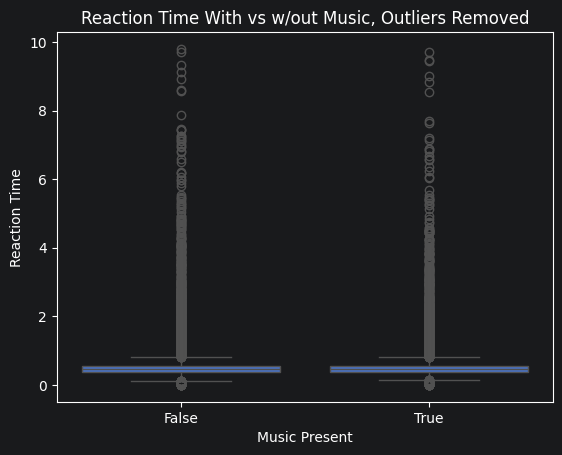

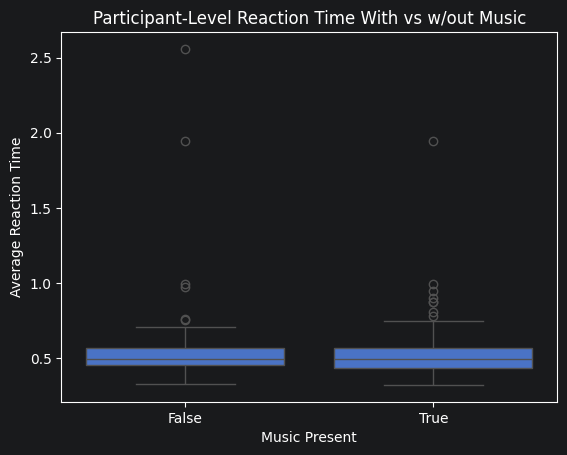

In [35]:
rt_clean = df[df['Reaction time'] < 10]

sns.boxplot(
    data=rt_clean,
    x='Music-present',
    y='Reaction time'
)

plt.xlabel("Music Present")
plt.ylabel("Reaction Time")
plt.title("Reaction Time With vs w/out Music, Outliers Removed")
plt.show()

participant_rt = (
    rt_clean
    .groupby(['ID', 'Music-present'])['Reaction time']
    .mean()
    .reset_index()
)

sns.boxplot(
    data=participant_rt,
    x='Music-present',
    y='Reaction time'
)

plt.xlabel("Music Present")
plt.ylabel("Average Reaction Time")
plt.title("Participant-Level Reaction Time With vs w/out Music")
plt.show()



The first plot shows the reaction time of participants with reaction time cutoff after 10ms with and without music, we cut off data after 10ms because of the existence of large outliers likely being negligible. To account for any outliers in our analysis we produced a second plot that shows the average reaction time of participants with and w/out music. For each plot looking at their two respective boxplots the medians are close, and the distributions in general for music and no music conditions are very similar. We can conclude that music does not appear to have a large effect on reaction time or average reaction time.


In [ ]:
participant_summary = (
    df
    .dropna(subset=['Mood', 'Arousal', 'Thought probe'])
    .groupby(['ID', 'Music-present'])[['Mood', 'Arousal', 'Thought probe']]
    .mean()
    .reset_index()
)

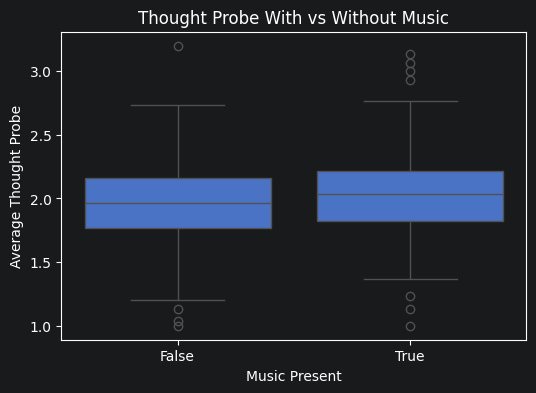

In [27]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Thought probe'
)

plt.xlabel("Music Present")
plt.ylabel("Average Thought Probe")
plt.title("Thought Probe With vs Without Music")
plt.show()


Similarly to reaction time we see that thought probe with both conditions is very similar. So we can hypothesize that music does not heavily affect thought probe. To further explain thought probe it is the psychological research term where participants are frequently interrupted during a task and are asked to report where there attention is directed and for how long. It essentially measures and maps how our brains focus on tasks and are able to manage our internal or unrelated thoughts.

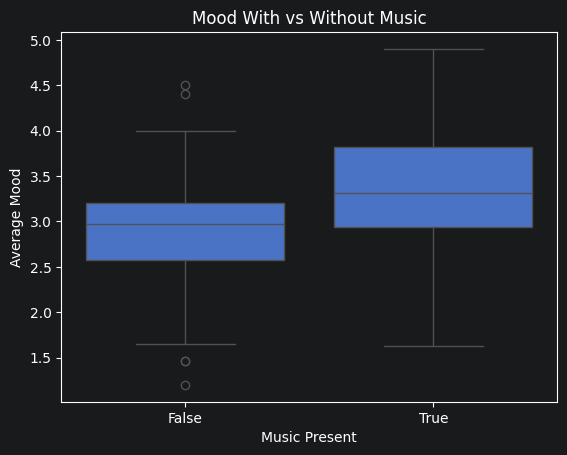

In [29]:

participant_summary.head()


sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Mood'
)

plt.xlabel("Music Present")
plt.ylabel("Average Mood")
plt.title("Mood With vs Without Music")
plt.show()

When music is present mood has a visibly higher median score than the no music condition. There is still some overlap between the groups but this overall trend suggests a positive association between mood and music.

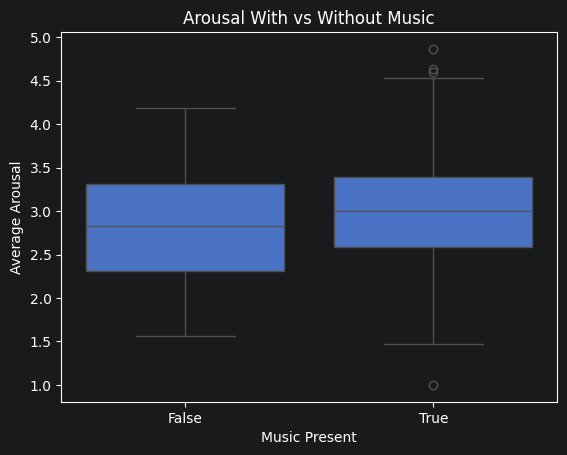

In [30]:

sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Arousal'
)

plt.xlabel("Music Present")
plt.ylabel("Average Arousal")
plt.title("Arousal With vs Without Music")
plt.show()

Even with a slightly higher median the boxplots overlap a lot, so music and its effect on arousal is weaker than mood.

In [14]:
df['Thought probe'].value_counts(dropna=False)

summary_table = df.groupby('Music-present')[
    ['Reaction time', 'Mood', 'Arousal', 'Thought probe']
].agg(
    ['mean', 'median', 'std']
)

summary_table

Reaction time                         Mood                   \
                       mean   median       std      mean median       std   
Music-present                                                               
False              0.584898  0.45553  2.589622  2.915118    3.0  0.952549   
True               0.542672  0.45310  1.745790  3.365574    3.0  0.983679   

                Arousal                  Thought probe                   
                   mean median       std          mean median       std  
Music-present                                                            
False          2.832605    3.0  1.110342      1.953370    2.0  0.836634  
True           3.024408    3.0  1.114237      2.047359    2.0  0.778150

This table gives us a numerical summary of what our plotting is generally trying to answer. It groups the data by mean, median, standard deviation for reaction time, mood, arousal, and thought probe. We see that music doesn't generally effect reaction time and thought probe due to the fact that the mean for both conditions were similar. Music does seem to be highly associated with higher mood and higher arousal, with a noticably higher mean.

In [28]:
from scipy.stats import ttest_rel

variables = ['Reaction time', 'Mood', 'Arousal', 'Thought probe']

for var in variables:
    # Optional: use cleaned reaction time only for Reaction time
    if var == 'Reaction time':
        temp_df = df[df['Reaction time'] < 10].copy()
    else:
        temp_df = df.copy()

    # Average each variable by participant and music condition
    summary = (
        temp_df
        .dropna(subset=[var])
        .groupby(['ID', 'Music-present'])[var]
        .mean()
        .reset_index()
    )

    # Make one column for No Music and one for Music
    wide = summary.pivot(
        index='ID',
        columns='Music-present',
        values=var
    )

    wide.columns = ['No_Music', 'Music']
    wide = wide.dropna()

    # Paired t-test
    result = ttest_rel(
        wide['Music'],
        wide['No_Music']
    )

    print(var)
    print(f"No Music mean: {wide['No_Music'].mean():.3f}")
    print(f"Music mean: {wide['Music'].mean():.3f}")
    print(f"t({result.df}) = {result.statistic:.3f}, p = {result.pvalue:.3f}")
    print()

Reaction time
No Music mean: 0.551
Music mean: 0.537
t(114) = -0.799, p = 0.426

Mood
No Music mean: 2.890
Music mean: 3.356
t(114) = 7.964, p = 0.000

Arousal
No Music mean: 2.814
Music mean: 3.002
t(114) = 3.919, p = 0.000

Thought probe
No Music mean: 1.949
Music mean: 2.043
t(114) = 2.791, p = 0.006



These are four ttests done on each variable: Mood, Arousal, Thought Probe, and Reaction. We see that for our p-tests the results are meaningful for mood, arousal, and thought probe while it shouldn't be meaningful for reaction time. For t-test we see that it is extremely low for reaction time as well compared to other variables. We can conclude that for mood, arousal, and thought probe they were all affected by music trials while reaction time was not.


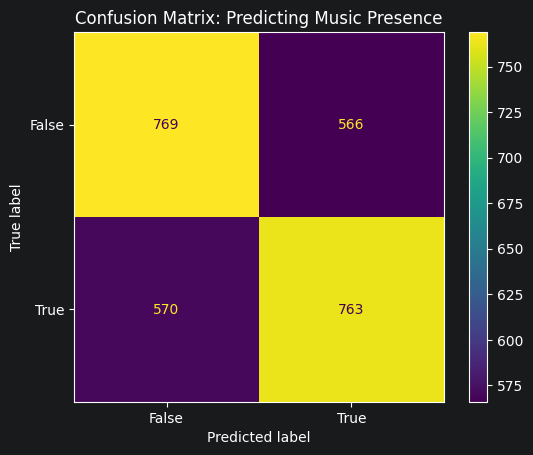

              precision    recall  f1-score   support

       False       0.57      0.58      0.58      1335
        True       0.57      0.57      0.57      1333

    accuracy                           0.57      2668
   macro avg       0.57      0.57      0.57      2668
weighted avg       0.57      0.57      0.57      2668



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model_df = df[['Reaction time', 'Mood', 'Arousal', 'Thought probe', 'Music-present']].dropna()

X = model_df[['Reaction time', 'Mood', 'Arousal', 'Thought probe']]
y = model_df['Music-present']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

music_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

music_clf.fit(X_train, y_train)

y_pred = music_clf.predict(X_test)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=music_clf.classes_
).plot()

plt.title("Confusion Matrix: Predicting Music Presence")
plt.show()

print(classification_report(y_test, y_pred))

This is a confusion matrix as well as a classification report to conclude the analysis on this dataset, looking at all four variables: Arousal, Mood, Reaction Time, and Thought Probe.

The confusion matrix tells us that our classifier was only moderately successful at even determining music was present. It correctly classified 769 no-music and 763 music trials, but it also misclassified 566 no-music trails and 570 music trials. Looking at our report we see that our model accuracy sat around 57% which is only slightly above chance (50%).



Since we believe that reaction time and thought probe are generally unaffected by music while mood and arousal are, we've ran two more confusion matrices to reinforce our findings

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

def run_music_classifier(feature_cols, title, filter_reaction_time=False):

    model_df = df[feature_cols + ['Music-present']].dropna().copy()

    # Optional: remove extreme reaction time outliers
    if filter_reaction_time and 'Reaction time' in feature_cols:
        model_df = model_df[model_df['Reaction time'] < 10]

    X = model_df[feature_cols]
    y = model_df['Music-present']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print(title)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=clf.classes_,
        yticklabels=clf.classes_
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.show()

    return clf

Confusion Matrix: Predicting Music Presence from Reaction Time and Thought Probe
              precision    recall  f1-score   support

       False       0.50      0.52      0.51      1333
        True       0.50      0.49      0.50      1333

    accuracy                           0.50      2666
   macro avg       0.50      0.50      0.50      2666
weighted avg       0.50      0.50      0.50      2666



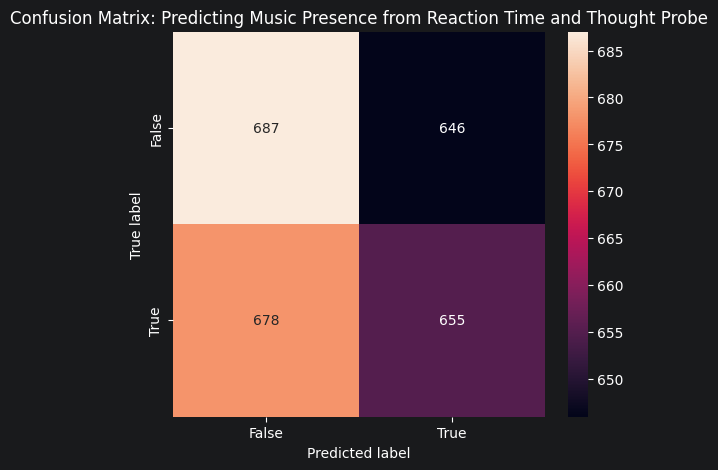

In [32]:
performance_clf = run_music_classifier(
    feature_cols=['Reaction time', 'Thought probe'],
    title='Confusion Matrix: Predicting Music Presence from Reaction Time and Thought Probe',
    filter_reaction_time=True
)

This machine learning confusion matrix which is synthetic reinforces our understanding that reaction time and thought probe don't seem to strongly distinguish music trials from no-music trials. With an accuracy of 1342 / 2666 = 50.3% which is ~chance.

Confusion Matrix: Predicting Music Presence from Mood and Arousal
              precision    recall  f1-score   support

       False       0.56      0.38      0.45      1373
        True       0.53      0.70      0.61      1372

    accuracy                           0.54      2745
   macro avg       0.55      0.54      0.53      2745
weighted avg       0.55      0.54      0.53      2745



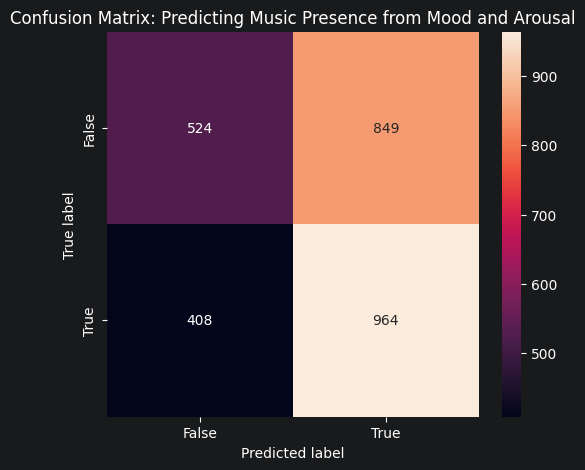

In [33]:
mental_state_clf = run_music_classifier(
    feature_cols=['Mood', 'Arousal'],
    title='Confusion Matrix: Predicting Music Presence from Mood and Arousal',
    filter_reaction_time=False
)

This second confusion matrix focused more on mood and arousal it had an accuracy of 1488 / 2745 = 54.2%. This is not amazing but it is much better than chance and the above model just looking at thought probe and reaction time. This generally must suggest that music makes participants feel more alert and activated more in terms of how they psychologically feel than how they may do in certain tasks. We also ran this machine learning to look at the differences between our collected dataset versus a synthetic dataset and they seemed to report very similar findings.